In [1]:


# --- Manejo de datos ---
import pandas as pd
import numpy as np

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocesamiento ---
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# --- Modelado (Clasificación y Clustering) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

# --- Evaluación de modelos ---
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# --- Configuración general ---
pd.set_option('display.max_columns', None)

# --- Suprimir advertencias ---
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv(r"C:\Users\saray\OneDrive\Documentos\proyectos\1 experimento\delitos.csv\delitos.csv", encoding='ISO-8859-1')

In [3]:
df

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Marzo,Abril
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2,1
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,0,0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,2,2
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0,1
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,0
...,...,...,...,...,...,...,...,...,...
15675,2019,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Falsificación,Falsificación,Falsificación,10,14
15676,2019,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Contra el medio ambiente,Contra el medio ambiente,Contra el medio ambiente,0,0
15677,2019,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,41,18
15678,2019,32,Zacatecas,Otros bienes jurídicos afectados (del fuero co...,Electorales,Electorales,Electorales,0,0


In [4]:
df=df[['Clave_Ent','Año','Marzo','Abril','Entidad','Tipo de delito','Subtipo de delito','Modalidad','Bien jurídico afectado']]

In [5]:
df=df.rename(columns={'Tipo de delito':'Tipo_delito','Subtipo de delito':'Subtipo_delito','Bien jurídico afectado':'Bien_juridico_afectado'})

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15680 entries, 0 to 15679
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Clave_Ent               15680 non-null  int64 
 1   Año                     15680 non-null  int64 
 2   Marzo                   15680 non-null  int64 
 3   Abril                   15680 non-null  int64 
 4   Entidad                 15680 non-null  object
 5   Tipo_delito             15680 non-null  object
 6   Subtipo_delito          15680 non-null  object
 7   Modalidad               15680 non-null  object
 8   Bien_juridico_afectado  15680 non-null  object
dtypes: int64(4), object(5)
memory usage: 1.1+ MB


Agrupamos variables

In [7]:
#Creo un diccionario

delitos_map={
    'Violencia_contra_personas':[ 'Robo', 'Homicidio', 'Lesiones', 'Secuestro', 'Feminicidio', 'Acoso sexual',
        'Abuso sexual', 'Violación simple', 'Violación equiparada', 'Incesto', 
        'Hostigamiento sexual', 'Violencia familiar', 
        'Violencia de género en todas sus modalidades distinta a la violencia familiar',
        'Rapto', 'Otros delitos que atentan contra la vida y la integridad corporal'
        ],
    'Delitos_contra_libertad':['Secuestro', 'Rapto', 'Otros delitos que atentan contra la libertad personal'
                               ],
                                   'Delitos sexuales': [
        'Feminicidio', 'Acoso sexual', 'Abuso sexual', 'Violación simple', 
        'Violación equiparada', 'Incesto', 'Hostigamiento sexual', 
        'Otros delitos que atentan contra la libertad y la seguridad sexual'
    ],
    'Delitos_contra_familia': [
        'Violencia familiar', 'Violencia de género en todas sus modalidades distinta a la violencia familiar', 
        'Incumplimiento de obligaciones de asistencia familiar', 'Otros delitos contra la familia'
    ],
    'Delitos_drugs_crimen_organizado': [
        'Narcomenudeo', 'Trata de personas'
    ],
    'Delitos_financieros': [
        'Fraude', 'Abuso de confianza', 'Falsedad', 'Falsificación', 'Corrupción de menores'
    ],
    'Delitos_contra_sociedad': [
        'Otros delitos contra la sociedad', 'Delitos cometidos por servidores públicos', 
        'Electorales', 'Contra el medio ambiente'
    ],
    'Delitos_menores': [
        'Otros delitos del Fuero Común', 'Evasión de presos', 'Allanamiento de morada', 'Amenazas'
    ]

}

#Creo una funcion para asiganr categorias

def categorias(tipo_delito):
    for categoria,delitos in delitos_map.items():
        if tipo_delito in delitos:
            return categoria
    return 'Otros'
#Nueva columnna con las variables agrupadas

df['Tipos_delitos']=df['Tipo_delito'].apply(categorias)

print(df['Tipos_delitos'].value_counts())

Tipos_delitos
Violencia_contra_personas          11680
Otros                                960
Delitos_financieros                  800
Delitos_contra_sociedad              640
Delitos_menores                      640
Delitos_drugs_crimen_organizado      320
Delitos_contra_familia               320
Delitos sexuales                     160
Delitos_contra_libertad              160
Name: count, dtype: int64


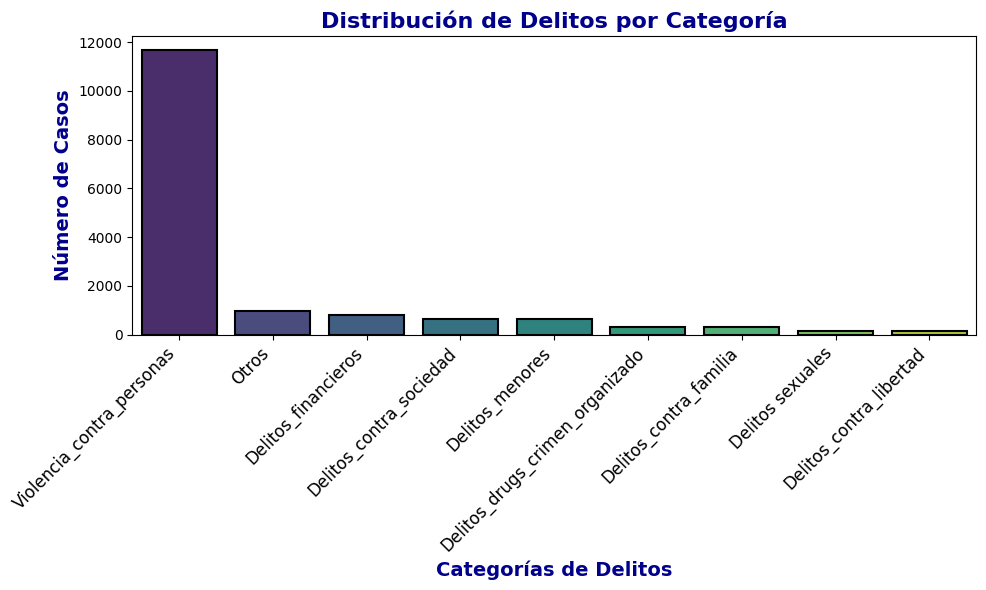

In [8]:
# Contamos la frecuencia de las nuevas categorías
categoria_counts = df['Tipos_delitos'].value_counts()

# Creo el gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=categoria_counts.index, y=categoria_counts.values, palette='viridis')

# Añado título y etiquetas
plt.title('Distribución de Delitos por Categoría', fontsize=16, weight='bold', color='darkblue')
plt.xlabel('Categorías de Delitos', fontsize=14, weight='bold', color='darkblue')
plt.ylabel('Número de Casos', fontsize=14, weight='bold', color='darkblue')

# Rotar las etiquetas para que sean más legibles
plt.xticks(rotation=45, ha='right', fontsize=12)

# Personalizo la apariencia de las barras
for bar in ax.patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1.5)

# Muestro el gráfico
plt.tight_layout()
plt.show()


In [9]:
df['Modalidad'].value_counts()

Modalidad
Sin violencia                                                                          1920
Con violencia                                                                          1920
Con arma de fuego                                                                       800
No especificado                                                                         800
Con otro elemento                                                                       800
Con arma blanca                                                                         800
En accidente de tránsito                                                                320
Secuestro extorsivo                                                                     160
Secuestro con calidad de rehén                                                          160
Aborto                                                                                  160
Otros delitos que atentan contra la vida y la integridad corporal     

Categorias_Modalidades
Delitos con violencia               4320
Delitos sin violencia               2720
Delitos relacionados con el robo    1920
Otros                               1280
Delitos sexuales                    1120
Delitos patrimoniales                960
Delitos menores                      960
Delitos contra la sociedad           960
Delitos de secuestro                 800
Delitos contra la familia            640
Name: count, dtype: int64


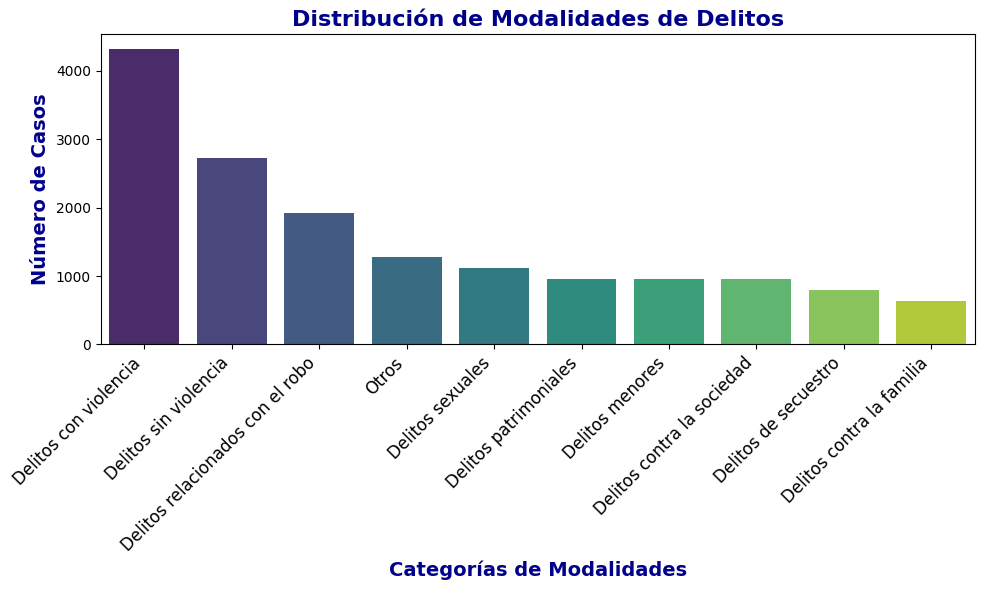

In [10]:
# Se crea un diccionario de agrupaciones de modalidades
modalidades_map = {
    'Delitos sin violencia': ['Sin violencia', 'No especificado'],
    'Delitos con violencia': ['Con violencia', 'Con arma de fuego', 'Con otro elemento', 'Con arma blanca', 'Robo con violencia'],
    'Delitos de secuestro': ['Secuestro extorsivo', 'Secuestro con calidad de rehén', 'Secuestro exprés', 'Secuestro para causar daño', 'Otro tipo de secuestros'],
    'Delitos relacionados con el robo': ['Robo de coche de 4 ruedas Con violencia', 'Robo de coche de 4 ruedas Sin violencia',
                                        'Robo de motocicleta Con violencia', 'Robo de motocicleta Sin violencia',
                                        'Robo de embarcaciones pequeñas y grandes Con violencia', 'Robo de embarcaciones pequeñas y grandes Sin violencia',
                                        'Robo de herramienta industrial o agrícola Con violencia', 'Robo de herramienta industrial o agrícola Sin violencia',
                                        'Robo de tractores Con violencia', 'Robo de tractores Sin violencia',
                                        'Robo de cables, tubos y otros objetos destinados a servicios públicos Con violencia', 'Robo de cables, tubos y otros objetos destinados a servicios públicos Sin violencia'],
    'Delitos sexuales': ['Abuso sexual', 'Acoso sexual', 'Violación simple', 'Violación equiparada', 'Incesto', 'Hostigamiento sexual', 'Otros delitos que atentan contra la libertad y la seguridad sexual'],
    'Delitos patrimoniales': ['Fraude', 'Abuso de confianza', 'Extorsión', 'Daño a la propiedad', 'Despojo', 'Otros delitos contra el patrimonio'],
    'Delitos contra la familia': ['Violencia familiar', 'Violencia de género en todas sus modalidades distinta a la violencia familiar', 
                                  'Incumplimiento de obligaciones de asistencia familiar', 'Otros delitos contra la familia'],
    'Delitos contra la sociedad': ['Corrupción de menores', 'Trata de personas', 'Otros delitos contra la sociedad', 
                                  'Delitos cometidos por servidores públicos', 'Electorales', 'Contra el medio ambiente'],
    'Delitos menores': ['Evasión de presos', 'Allanamiento de morada', 'Amenazas', 'Otros delitos del Fuero Común', 'Falsedad', 'Falsificación']
}

# Función para asignar categorías a las modalidades
def categorias_modalidad(modalidad):
    for categoria, delitos in modalidades_map.items():
        if modalidad in delitos:
            return categoria
    return 'Otros'  # Si no coincide con ninguna categoría, lo asignamos a "Otros"

# Crear una nueva columna 'Categorias_Modalidades' con las categorías asignadas
df['Categorias_Modalidades'] = df['Modalidad'].apply(categorias_modalidad)

# Ver las cuentas de las categorías
print(df['Categorias_Modalidades'].value_counts())

# Ahora, graficamos la distribución de las categorías de modalidades
import matplotlib.pyplot as plt
import seaborn as sns

# Contamos la frecuencia de las nuevas categorías
modalidad_counts = df['Categorias_Modalidades'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=modalidad_counts.index, y=modalidad_counts.values, palette='viridis')

# Añadir título y etiquetas
plt.title('Distribución de Modalidades de Delitos', fontsize=16, weight='bold', color='darkblue')
plt.xlabel('Categorías de Modalidades', fontsize=14, weight='bold', color='darkblue')
plt.ylabel('Número de Casos', fontsize=14, weight='bold', color='darkblue')

# Rotar las etiquetas para que sean más legibles
plt.xticks(rotation=45, ha='right', fontsize=12)

# Personalizar la apariencia de las barras
plt.tight_layout()
plt.show()

In [11]:
df['Subtipo_delito'].value_counts()

Subtipo_delito
Robo de vehículo automotor                                                       960
Robo de maquinaria                                                               960
Lesiones culposas                                                                800
Secuestro                                                                        800
Homicidio culposo                                                                800
Lesiones dolosas                                                                 640
Feminicidio                                                                      640
Homicidio doloso                                                                 640
Robo a transportista                                                             320
Robo a casa habitación                                                           320
Robo a transeúnte en vía pública                                                 320
Robo en transporte público individual             

In [ ]:
# Se crea un diccionario para mapear los subtipo del delito a categorías
delitos_subtipo_map = {
    'Delitos_contra_vida_integridad': [
        'Homicidio culposo', 'Homicidio doloso', 'Feminicidio', 'Lesiones culposas',
        'Lesiones dolosas', 'Violencia familiar', 'Violencia de género en todas sus modalidades distinta a la violencia familiar',
        'Otros delitos que atentan contra la vida y la integridad corporal'
    ],
    'Delitos_contra_patrimonio': [
        'Robo de vehículo automotor', 'Robo de maquinaria', 'Robo a casa habitación', 'Robo a transeúnte en vía pública',
        'Robo en transporte público individual', 'Robo a negocio', 'Robo a institución bancaria', 'Robo de autopartes',
        'Robo de ganado', 'Robo a transportista', 'Robo de herramienta industrial o agrícola', 'Otros robos',
        'Daño a la propiedad', 'Despojo', 'Otros delitos contra el patrimonio'
    ],
    'Delitos_sexuales': [
        'Abuso sexual', 'Acoso sexual', 'Hostigamiento sexual', 'Violación simple', 'Violación equiparada',
        'Incesto', 'Otros delitos que atentan contra la libertad y la seguridad sexual'
    ],
    'Delitos_contra_libertad_personal': [
        'Secuestro', 'Rapto', 'Secuestro exprés', 'Secuestro extorsivo', 'Secuestro con calidad de rehén',
        'Secuestro para causar daño', 'Otro tipo de secuestros', 'Tráfico de menores', 'Otros delitos que atentan contra la libertad personal'
    ],
    'Delitos_economicos_financieros': [
        'Fraude', 'Abuso de confianza', 'Extorsión', 'Falsedad', 'Falsificación', 'Corrupción de menores', 'Delitos cometidos por servidores públicos'
    ],
    'Delitos_contra_sociedad_orden_publico': [
        'Narcomenudeo', 'Amenazas', 'Allanamiento de morada', 'Evasión de presos', 'Otros delitos contra la sociedad',
        'Electorales', 'Contra el medio ambiente', 'Otros delitos del Fuero Común'
    ],
    'Delitos_familia': [
        'Incumplimiento de obligaciones de asistencia familiar', 'Otros delitos contra la familia'
    ],
    'Otros_delitos': [
        'Aborto', 'Otros delitos que atentan contra la libertad y la seguridad sexual', 'Otros delitos del Fuero Común'
    ]
}

# Función para asignar categorías de delito
def categorizar_subtipo_delito(subtipo):
    for categoria, delitos in delitos_subtipo_map.items():
        if subtipo in delitos:
            return categoria
    return 'Otros'

# Aplicamos la función para crear una nueva columna con las categorías
df['Categorias_Subtipo'] = df['Subtipo_delito'].apply(categorizar_subtipo_delito)

# Verificamos las nuevas categorías
print(df['Categorias_Subtipo'].value_counts())


Categorias_Subtipo
Delitos_contra_patrimonio                5280
Delitos_contra_vida_integridad           4000
Delitos_contra_libertad_personal         1280
Delitos_contra_sociedad_orden_publico    1280
Delitos_sexuales                         1120
Delitos_economicos_financieros           1120
Otros                                    1120
Delitos_familia                           320
Otros_delitos                             160
Name: count, dtype: int64


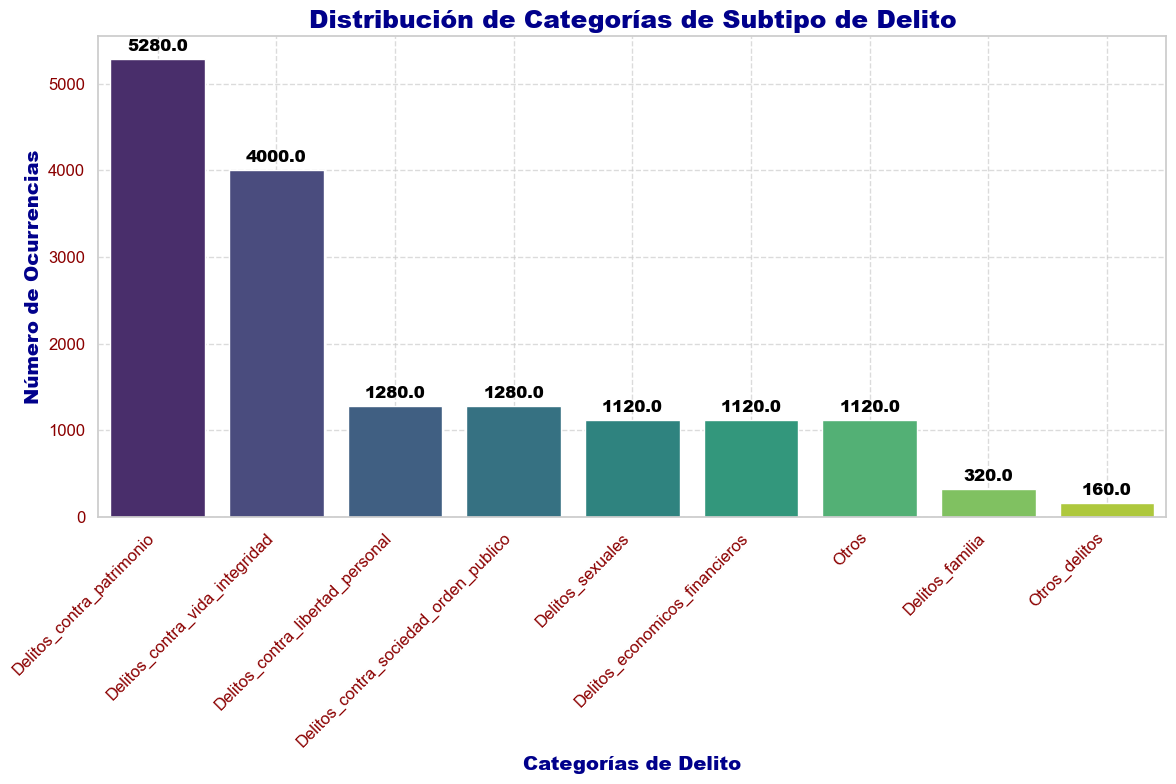

In [13]:
# Configuración del estilo
sns.set_theme(style="whitegrid", palette="coolwarm")

# Contar el número de ocurrencias de cada categoría
categoria_counts = df['Categorias_Subtipo'].value_counts()

# Crear la figura y el eje
plt.figure(figsize=(12, 8))

# Crear el gráfico de barras
ax = sns.barplot(x=categoria_counts.index, y=categoria_counts.values, palette="viridis")

# Mejorar la apariencia del gráfico
plt.title('Distribución de Categorías de Subtipo de Delito', fontsize=18, weight='black', color='darkblue')
plt.xlabel('Categorías de Delito', fontsize=14, weight='black', color='darkblue')
plt.ylabel('Número de Ocurrencias', fontsize=14, weight='black', color='darkblue')
plt.xticks(rotation=45, ha='right', fontsize=12, color='darkred')
plt.yticks(fontsize=12, color='darkred')

# Añadir etiquetas encima de las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', weight='black', xytext=(0, 9),
                textcoords='offset points')

# Ajustar el fondo y otros elementos
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


In [14]:
# Elimino las columnas 'Tipo_delito' y 'Modalidad'
df = df.drop(columns=['Tipo_delito', 'Modalidad','Subtipo_delito'])

# Ahora veo las primeras filas del DataFrame para asegurarte que las columnas fueron eliminadas correctamente
print(df.head())

   Clave_Ent   Año  Marzo  Abril         Entidad  \
0          1  2015      2      1  Aguascalientes   
1          1  2015      0      0  Aguascalientes   
2          1  2015      2      2  Aguascalientes   
3          1  2015      0      1  Aguascalientes   
4          1  2015      0      0  Aguascalientes   

             Bien_juridico_afectado              Tipos_delitos  \
0  La vida y la Integridad corporal  Violencia_contra_personas   
1  La vida y la Integridad corporal  Violencia_contra_personas   
2  La vida y la Integridad corporal  Violencia_contra_personas   
3  La vida y la Integridad corporal  Violencia_contra_personas   
4  La vida y la Integridad corporal  Violencia_contra_personas   

  Categorias_Modalidades              Categorias_Subtipo  
0  Delitos con violencia  Delitos_contra_vida_integridad  
1  Delitos con violencia  Delitos_contra_vida_integridad  
2  Delitos con violencia  Delitos_contra_vida_integridad  
3  Delitos sin violencia  Delitos_contra_vida_integrid

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15680 entries, 0 to 15679
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Clave_Ent               15680 non-null  int64 
 1   Año                     15680 non-null  int64 
 2   Marzo                   15680 non-null  int64 
 3   Abril                   15680 non-null  int64 
 4   Entidad                 15680 non-null  object
 5   Bien_juridico_afectado  15680 non-null  object
 6   Tipos_delitos           15680 non-null  object
 7   Categorias_Modalidades  15680 non-null  object
 8   Categorias_Subtipo      15680 non-null  object
dtypes: int64(4), object(5)
memory usage: 1.1+ MB


4. Análisis de Modalidades y Subtipos de Delitos 

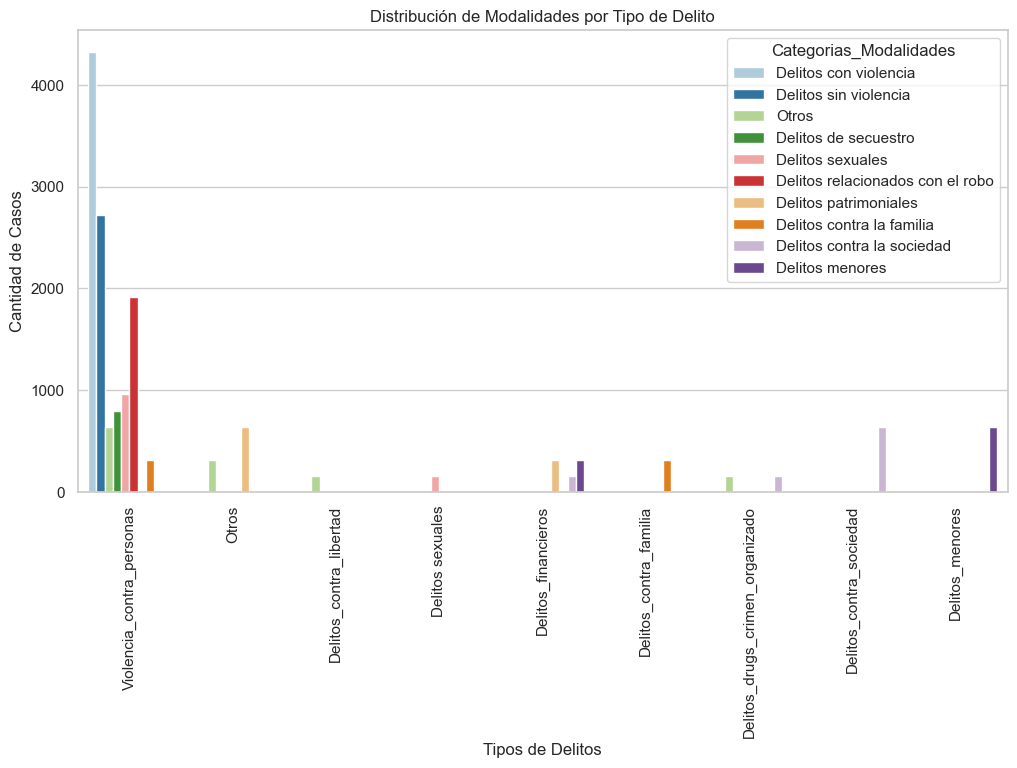

In [ ]:
# Comparo modalidad y tipo de delito
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Tipos_delitos', hue='Categorias_Modalidades', palette='Paired')
plt.xticks(rotation=90)
plt.title('Distribución de Modalidades por Tipo de Delito')
plt.xlabel('Tipos de Delitos')
plt.ylabel('Cantidad de Casos')
plt.show()


1. Análisis de tendencias de tiempo


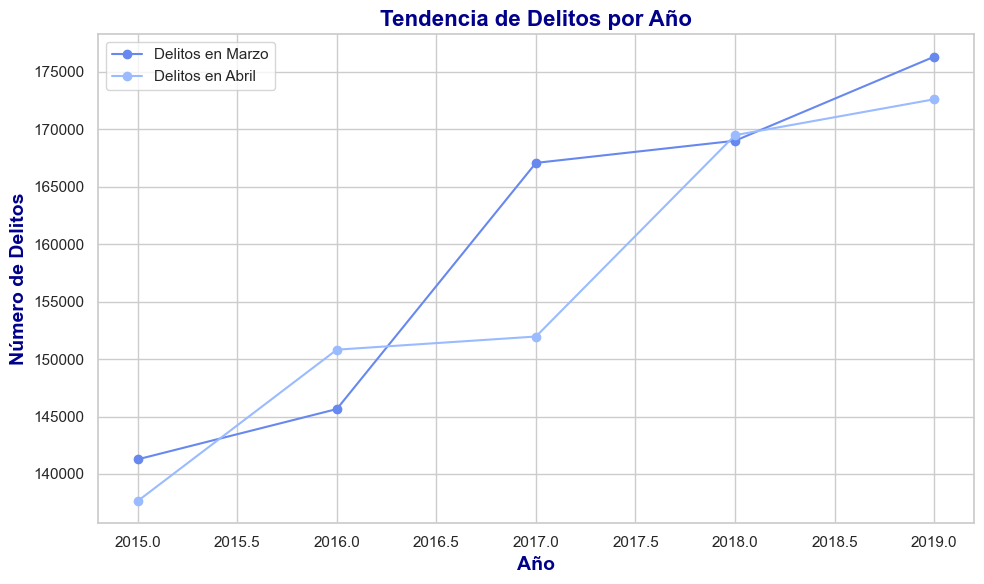

In [17]:
# Agrupo por 'Año' y luego sumar las columnas 'Marzo' y 'Abril'
delitos_por_ano = df.groupby('Año')[['Marzo', 'Abril']].sum()

# Crear un gráfico de líneas para ver la evolución de los delitos a lo largo de los años
plt.figure(figsize=(10, 6))
plt.plot(delitos_por_ano.index, delitos_por_ano['Marzo'], label='Delitos en Marzo', marker='o')
plt.plot(delitos_por_ano.index, delitos_por_ano['Abril'], label='Delitos en Abril', marker='o')
plt.title('Tendencia de Delitos por Año', fontsize=16, weight='bold', color='darkblue')
plt.xlabel('Año', fontsize=14, weight='bold', color='darkblue')
plt.ylabel('Número de Delitos', fontsize=14, weight='bold', color='darkblue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1.2. Distribución de delitos por categorías a lo largo de los años


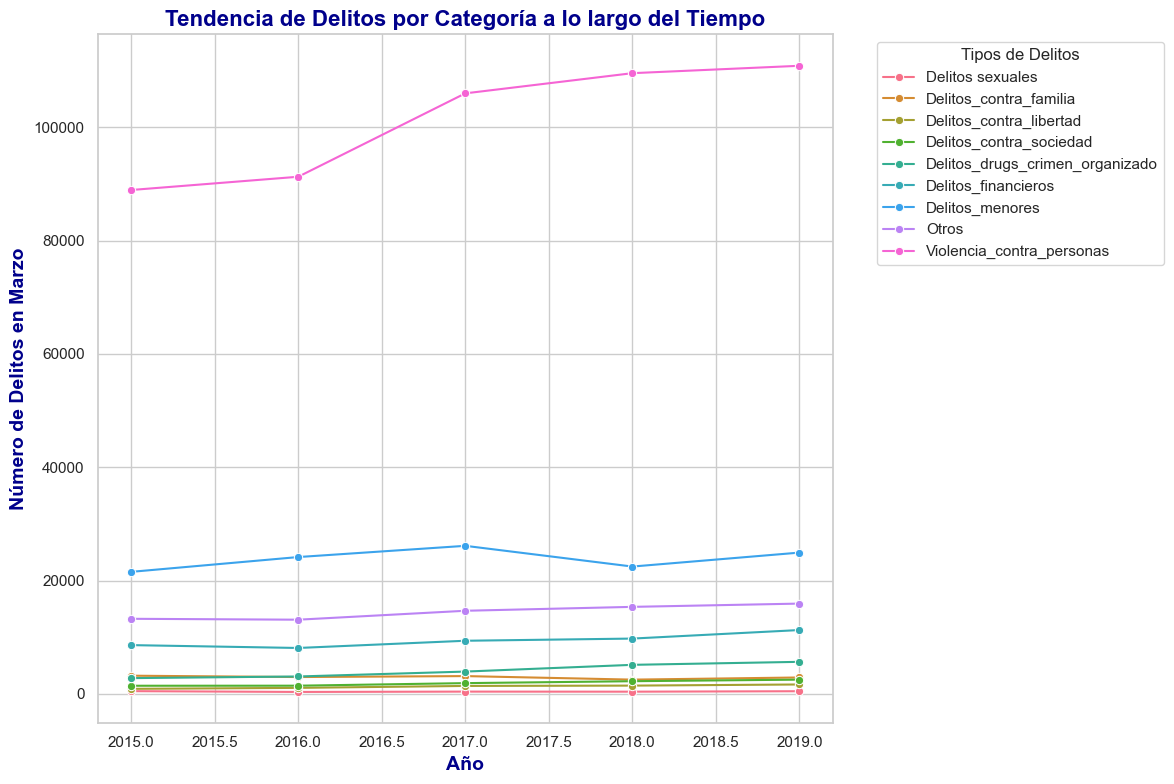

In [18]:
# Agrupar por año y tipo de delito
delitos_por_categoria = df.groupby(['Año', 'Tipos_delitos'])[['Marzo', 'Abril']].sum().reset_index()

# Crear un gráfico para visualizar la distribución de delitos por categorías a lo largo del tiempo
plt.figure(figsize=(12, 8))
sns.lineplot(data=delitos_por_categoria, x='Año', y='Marzo', hue='Tipos_delitos', marker='o')
plt.title('Tendencia de Delitos por Categoría a lo largo del Tiempo', fontsize=16, weight='bold', color='darkblue')
plt.xlabel('Año', fontsize=14, weight='bold', color='darkblue')
plt.ylabel('Número de Delitos en Marzo', fontsize=14, weight='bold', color='darkblue')
plt.legend(title='Tipos de Delitos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


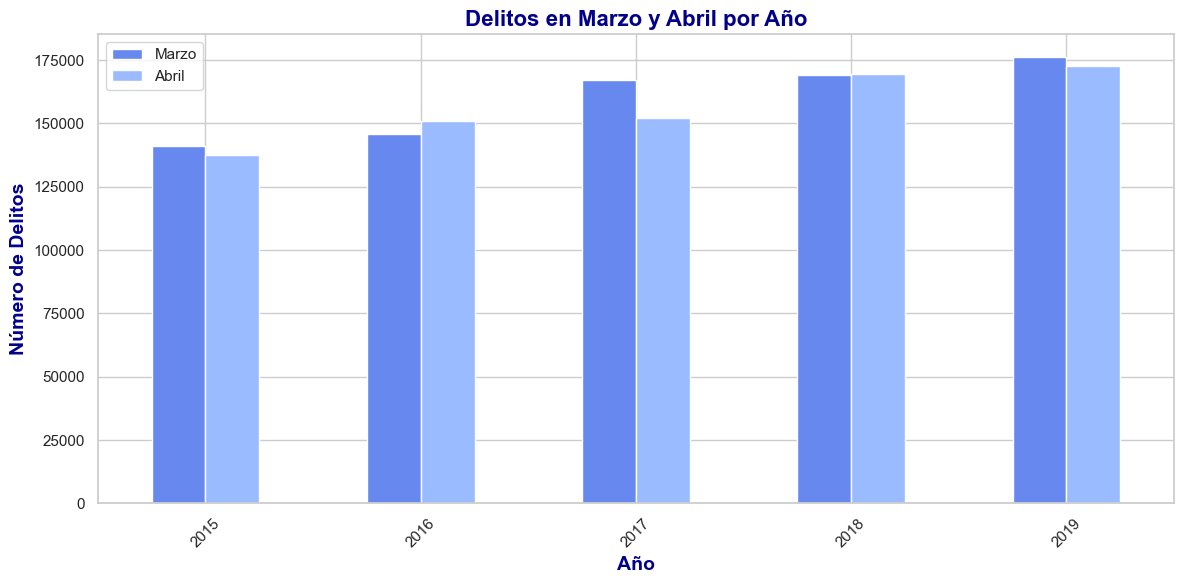

In [ ]:
# Agrupo por año y modalidad (Marzo y Abril) para analizar tendencias mensuales
tendencias_mensuales = df.groupby('Año')[['Marzo', 'Abril']].sum()

# Creo un gráfico de barras para comparar los delitos en marzo y abril de cada año
tendencias_mensuales.plot(kind='bar', figsize=(12, 6))
plt.title('Delitos en Marzo y Abril por Año', fontsize=16, weight='bold', color='darkblue')
plt.xlabel('Año', fontsize=14, weight='bold', color='darkblue')
plt.ylabel('Número de Delitos', fontsize=14, weight='bold', color='darkblue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Entreno el Modelo


1. Preparación de Datos: Separar características y variable objetivo


In [20]:
# Separar características y variable objetivo
X = df.drop(columns=['Tipos_delitos'])  # Características
y = df['Tipos_delitos']  # Variable objetivo


2. Dividir los datos en conjuntos de entrenamiento y prueba
python
Copy code


In [21]:
# Dividir el conjunto de datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


3. Preprocesamiento de variables categóricas


In [22]:
# Columnas categóricas y numéricas
categorical_columns = X.select_dtypes(include=['object']).columns
numerical_columns = X.select_dtypes(exclude=['object']).columns

# Crear un preprocesador para transformar las variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_columns),  # OneHot Encoding para variables categóricas
        ('num', 'passthrough', numerical_columns)  # Pasar las variables numéricas sin cambios
    ])


4. Entrenar el modelo usando Random Forest


In [23]:
# Crear un modelo de Random Forest y un pipeline que combine preprocesamiento y el modelo
model = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocesamiento de datos
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))  # Random Forest
])

# Entrenar el modelo
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  Index(['Entidad', 'Bien_juridico_afectado', 'Categorias_Modalidades',
       'Categorias_Subtipo'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Clave_Ent', 'Año', 'Marzo', 'Abril'], dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

5. Evaluo el modelo


In [ ]:
# Hago predicciones sobre los datos de prueba
y_pred = model.predict(X_test)

# Evaluo el rendimiento del modelo
print("Accuracy:", accuracy_score(y_test, y_pred))  # Precisión del modelo
print("\nClassification Report:\n", classification_report(y_test, y_pred))  # Reporte completo con métricas


Accuracy: 0.967155612244898

Classification Report:
                                  precision    recall  f1-score   support

               Delitos sexuales       0.28      0.23      0.25        22
         Delitos_contra_familia       1.00      1.00      1.00        60
        Delitos_contra_libertad       0.89      0.86      0.88        37
        Delitos_contra_sociedad       1.00      1.00      1.00       132
Delitos_drugs_crimen_organizado       1.00      1.00      1.00        59
            Delitos_financieros       0.96      0.95      0.96       161
                Delitos_menores       1.00      1.00      1.00       129
                          Otros       0.81      0.86      0.83       199
      Violencia_contra_personas       0.98      0.98      0.98      2337

                       accuracy                           0.97      3136
                      macro avg       0.88      0.88      0.88      3136
                   weighted avg       0.97      0.97      0.97      3

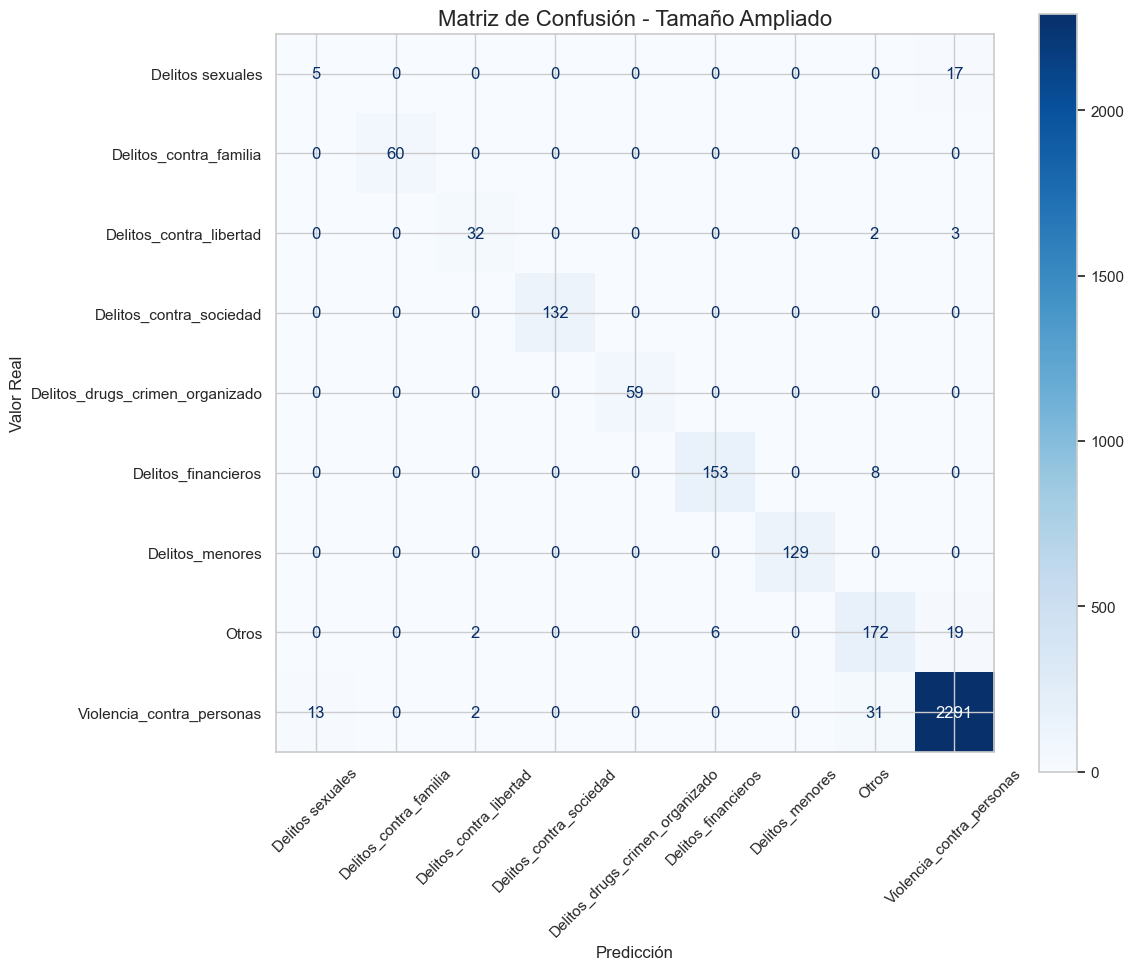

In [25]:

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Crear visualización con mayor tamaño
fig, ax = plt.subplots(figsize=(12, 10))  # Cambia el tamaño aquí
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)

plt.title("Matriz de Confusión - Tamaño Ampliado", fontsize=16)
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

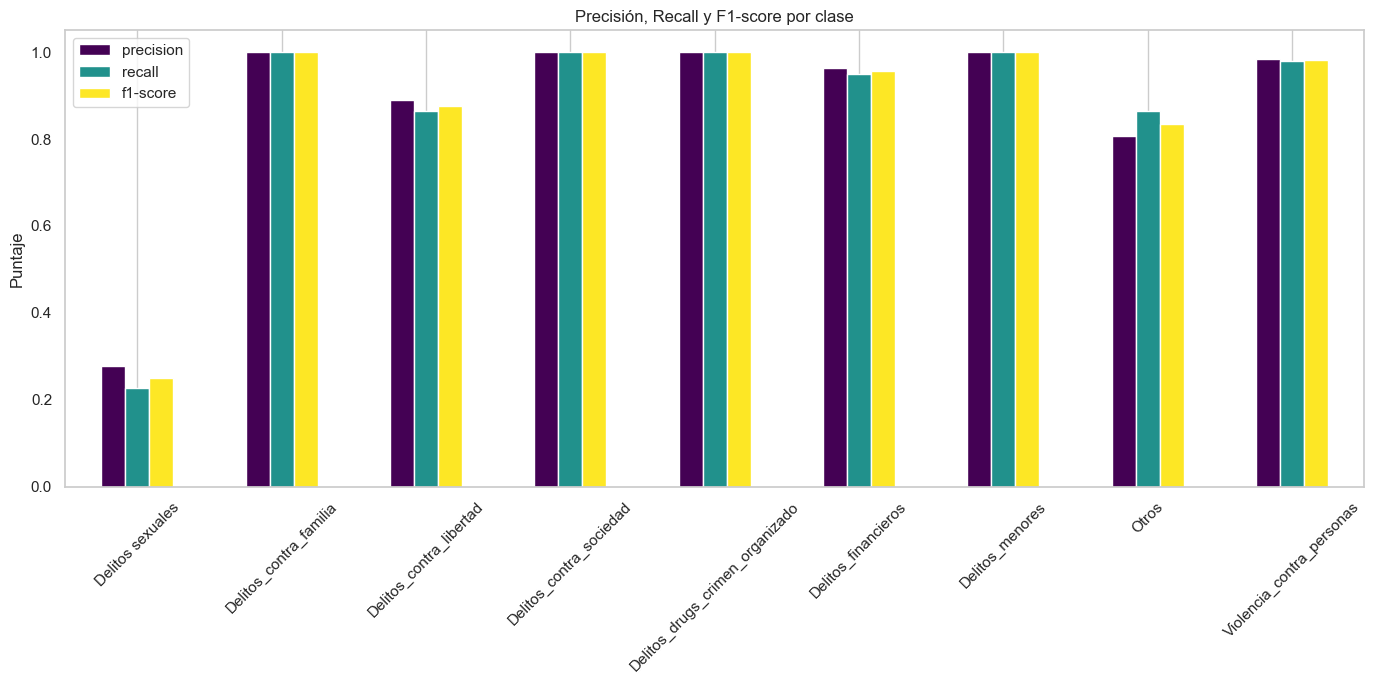

In [26]:

# Convertir el reporte de clasificación en DataFrame
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])

# Plot
plt.figure(figsize=(12, 6))
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 7), colormap='viridis')
plt.title("Precisión, Recall y F1-score por clase")
plt.ylabel("Puntaje")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
